In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import joblib

In [2]:
df=pd.read_csv(r"WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
#DATA CLEANING

In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#VIZUALIZATION

In [12]:
#ATTRIBUTION DISTRIBUTION

<Axes: xlabel='Attrition', ylabel='count'>

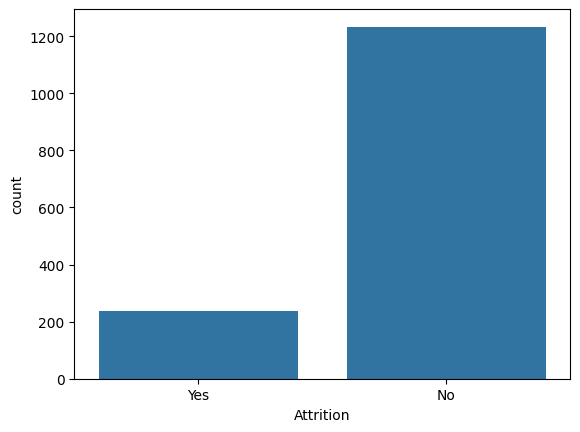

In [13]:
sns.countplot(x='Attrition', data=df)

In [14]:
#AGE DISTRIBUTION

<Axes: xlabel='Age', ylabel='Count'>

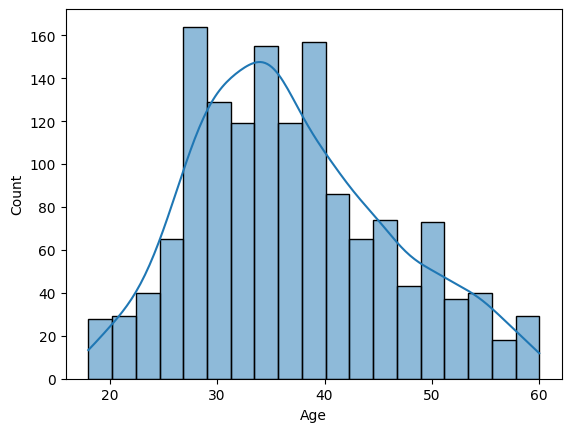

In [15]:
sns.histplot(df['Age'], kde=True)

In [16]:
#MONTHLY INCOM DISTRIBUTION

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

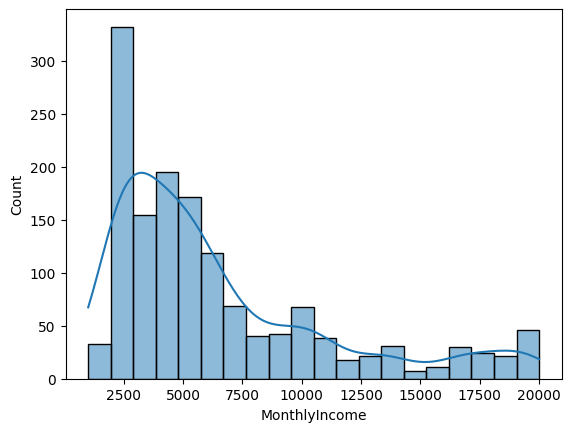

In [17]:
sns.histplot(df['MonthlyIncome'], kde=True)

In [18]:
#AGE VS ATTRITION

<Axes: xlabel='Attrition', ylabel='Age'>

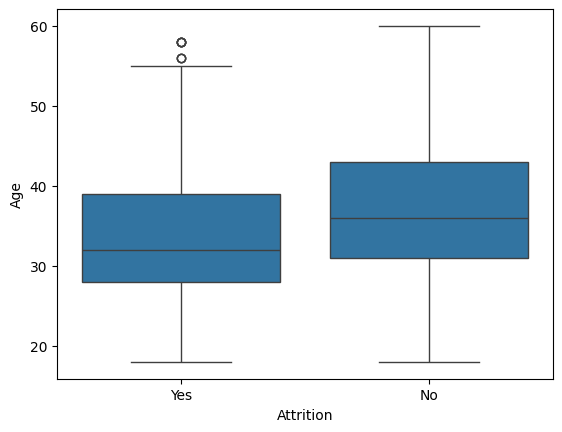

In [19]:
sns.boxplot(x='Attrition', y='Age', data=df)

In [20]:
#EDUCATION LEVEL DISTRIBUTION

<Axes: xlabel='Education', ylabel='count'>

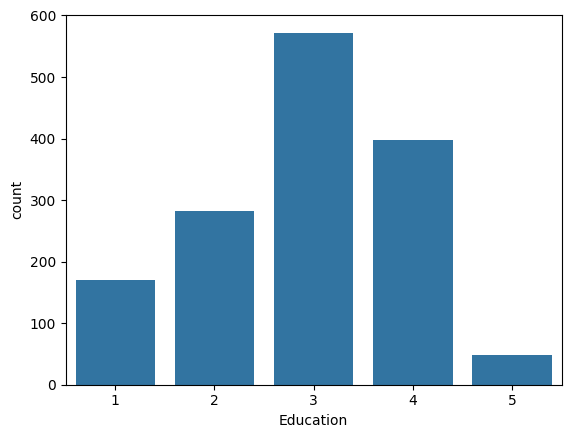

In [21]:
sns.countplot(x='Education', data=df)

In [22]:
#PAIRPLOT

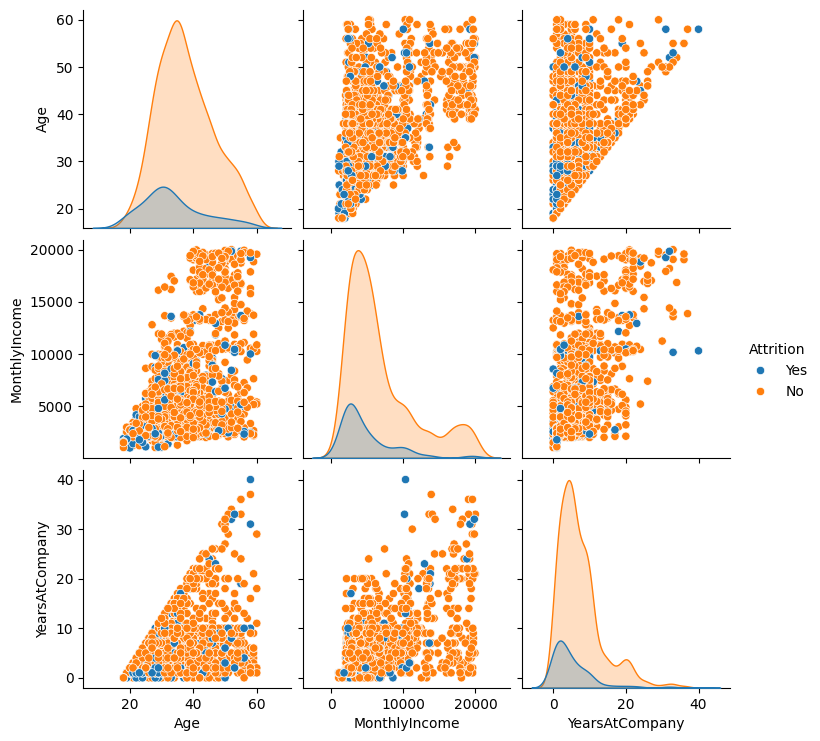

In [23]:
sns.pairplot(
    df[['Age','MonthlyIncome',
        'YearsAtCompany','Attrition']],
    hue='Attrition'
)

In [24]:
#SCATTER PLOT

<Axes: xlabel='Age', ylabel='MonthlyIncome'>

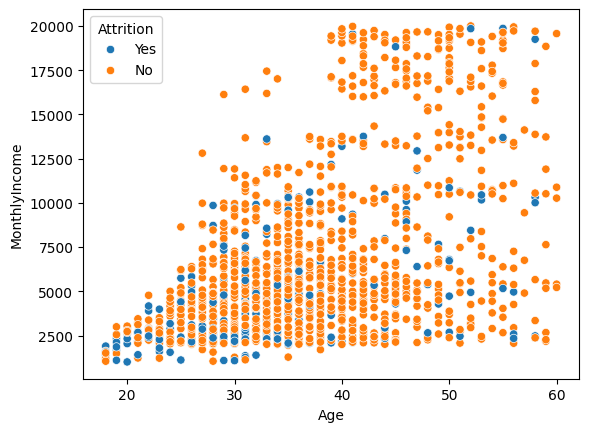

In [25]:
sns.scatterplot(
    x='Age',
    y='MonthlyIncome',
    hue='Attrition',
    data=df
)

In [26]:
#DATA PREPROCESSING

In [27]:
df.columns


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [28]:
df.drop(
    ['EmployeeCount','Over18',
     'StandardHours','EmployeeNumber'],
    axis=1,
    inplace=True
)

In [29]:
#Encode target variable

df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [30]:
#find categorical columns 

df.select_dtypes(include='object').columns

C:\Users\chind\AppData\Local\Temp\ipykernel_3384\1660935049.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')

In [31]:

label_encoders = {}

for col in df.select_dtypes(include='object'):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

C:\Users\chind\AppData\Local\Temp\ipykernel_3384\271399656.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


In [32]:
selected_features = [
    "Age",
    "MonthlyIncome",
    "OverTime",
    "YearsAtCompany",
    "Department",
    "JobRole",
    "JobSatisfaction"
]

X = df[selected_features]
y = df["Attrition"]

In [33]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
#MODEL DICTIONARY

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBoost": XGBClassifier()
}

In [36]:
#TRAINED AND EVALUATED ALL MODELS

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

In [37]:
#COMPARISON TABLE
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.863946,1.000000,0.148936,0.259259
5,Naive Bayes,0.850340,0.555556,0.319149,0.405405
4,SVM,0.843537,0.545455,0.127660,0.206897
1,KNN,0.840136,0.500000,0.234043,0.318841
6,AdaBoost,0.836735,0.473684,0.191489,0.272727
3,Random Forest,0.833333,0.450000,0.191489,0.268657
8,Extra Trees,0.833333,0.461538,0.255319,0.328767
7,Gradient Boosting,0.826531,0.416667,0.212766,0.281690
9,XGBoost,0.812925,0.366667,0.234043,0.285714
2,Decision Tree,0.748299,0.235294,0.255319,0.244898


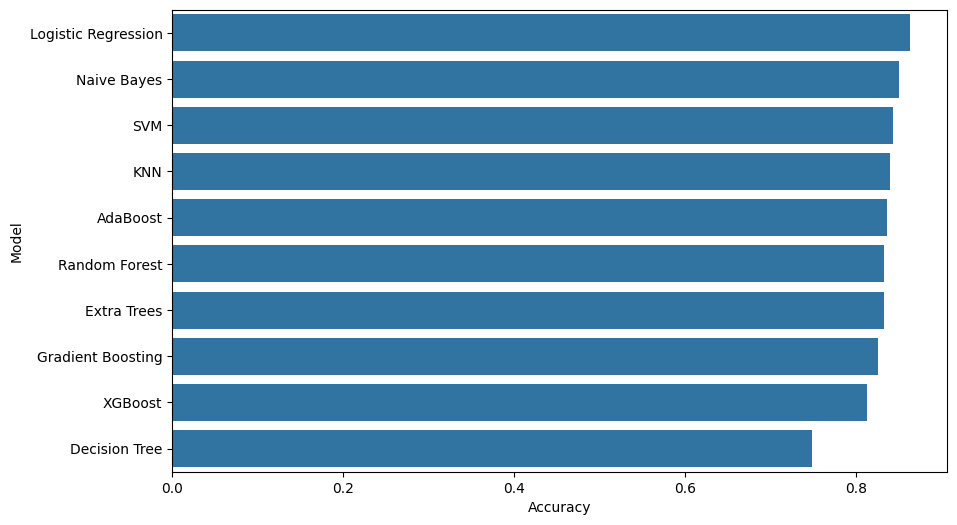

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df.sort_values(
        by="Accuracy",
        ascending=False
    ),
    x="Accuracy",
    y="Model"
)

plt.show()

In [39]:
best_model_name = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Model"
]

print(best_model_name)

Logistic Regression


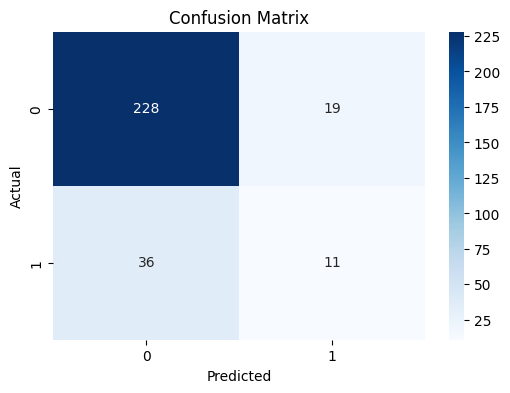

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
#CLASSIFICATION REPORT

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       247
           1       0.37      0.23      0.29        47

    accuracy                           0.81       294
   macro avg       0.62      0.58      0.59       294
weighted avg       0.78      0.81      0.80       294



In [42]:
# HYPERPARAMETER TUNING
 
params = {
    'C':[0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10}
0.20997304582210238


In [43]:

lr = LogisticRegression()

lr.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance['Importance'] = abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Importance
2,OverTime,0.615409,0.615409
4,Department,0.429633,0.429633
0,Age,-0.403381,0.403381
3,YearsAtCompany,-0.379889,0.379889
1,MonthlyIncome,-0.366705,0.366705
6,JobSatisfaction,-0.317760,0.317760
5,JobRole,-0.249579,0.249579


In [44]:

best_model = LogisticRegression()
best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(label_encoders, "label_encoders.joblib")

['label_encoders.joblib']

In [45]:


scaler = joblib.load("scaler.joblib")
print(scaler.feature_names_in_)

['Age' 'MonthlyIncome' 'OverTime' 'YearsAtCompany' 'Department' 'JobRole'
 'JobSatisfaction']


In [46]:
#python -m streamlit run app1.py

In [47]:
import joblib

model = joblib.load("best_model.joblib")
print("Features expected:", model.n_features_in_)

Features expected: 7


In [48]:
print(X.columns.tolist())


['Age', 'MonthlyIncome', 'OverTime', 'YearsAtCompany', 'Department', 'JobRole', 'JobSatisfaction']


In [49]:
print(label_encoders.keys())

dict_keys(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime'])


In [50]:
feature_names = [
    'Age',
    'MonthlyIncome',
    'OverTime',
    'YearsAtCompany',
    'Department',
    'JobRole',
    'JobSatisfaction'
]

joblib.dump(feature_names, "feature_names.joblib")

['feature_names.joblib']

In [51]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [52]:
joblib.dump(feature_names, "feature_names.joblib")

['feature_names.joblib']

In [53]:
import os
print(os.listdir())

['app1.py', 'best_model.joblib', 'classification_project.ipynb', 'Employee atrition dataset.zip', 'feature_names.joblib', 'label_encoders.joblib', 'model_columns.pkl', 'scaler.joblib', 'WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [54]:
print(label_encoders["OverTime"].classes_)
print(label_encoders["Department"].classes_)
print(label_encoders["JobRole"].classes_)

['No' 'Yes']
['Human Resources' 'Research & Development' 'Sales']
['Healthcare Representative' 'Human Resources' 'Laboratory Technician'
 'Manager' 'Manufacturing Director' 'Research Director'
 'Research Scientist' 'Sales Executive' 'Sales Representative']
